Processing dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

...

Validation: 100%|██████████| 64/64 [00:21<00:00,  2.99it/s]


Epoch 9: Train Loss=0.0701, Train Acc=97.8519, Val Loss=0.0762, Val Acc=97.6543


Validation: 100%|██████████| 64/64 [00:21<00:00,  3.00it/s]


Epoch 10: Train Loss=0.0604, Train Acc=98.2434, Val Loss=0.0731, Val Acc=97.8272


<ipython-input-1-43cc5ac55daa>:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_swin.pth"))


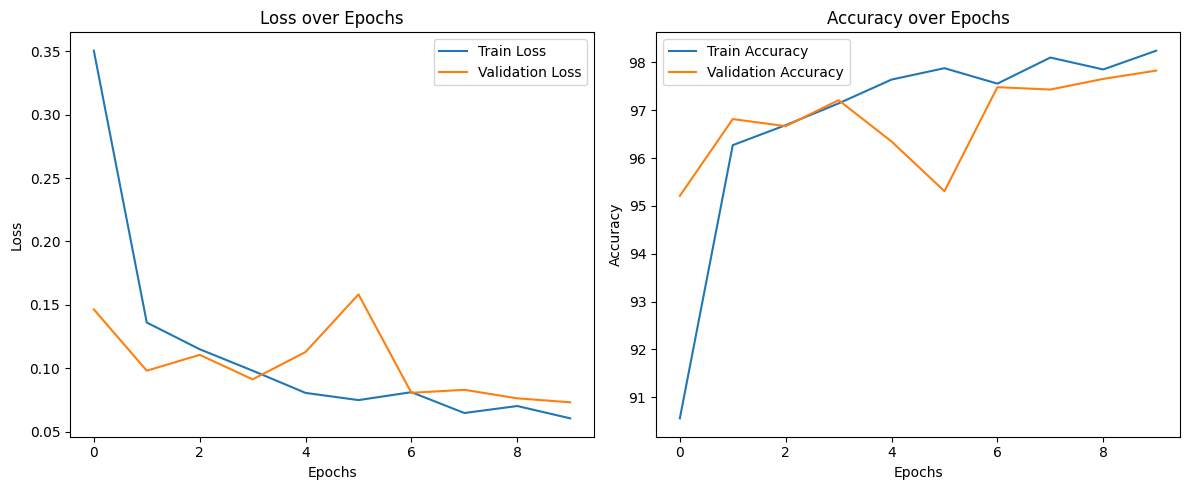


Test Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       437
           1       0.99      0.99      0.99       436
           2       0.98      0.97      0.98       473
           3       1.00      0.96      0.98       379
           4       0.99      1.00      0.99       372
           5       0.99      0.93      0.96       301
           6       0.93      0.97      0.95       393
           7       0.98      1.00      0.99       454
           8       0.96      0.99      0.98       353
           9       1.00      0.99      0.99       452

    accuracy                           0.98      4050
   macro avg       0.98      0.98      0.98      4050
weighted avg       0.98      0.98      0.98      4050



In [ ]:
import os
import torch
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import timm
from PIL import Image

# Constants
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10  # Increased to 10 epochs for visualization
PREPROCESSED_DIR = "/content/drive/MyDrive/preprocessed_eurosat"
dataset_fraction = 1


# Load or preprocess the dataset (same as before)
def load_or_preprocess_data(dataset_fraction=1.0, train_split=0.7, val_split=0.15, test_split=0.15):
    if train_split + val_split + test_split != 1.0:
        raise ValueError("Train, validation, and test splits must sum to 1.0")
    try:
        if os.path.exists(os.path.join(PREPROCESSED_DIR, "train_data.npz")):
            print("Loading preprocessed data...")
            with np.load(os.path.join(PREPROCESSED_DIR, "train_data.npz")) as data:
                train_images, train_labels = data['images'], data['labels']
            with np.load(os.path.join(PREPROCESSED_DIR, "val_data.npz")) as data:
                val_images, val_labels = data['images'], data['labels']
            with np.load(os.path.join(PREPROCESSED_DIR, "test_data.npz")) as data:
                test_images, test_labels = data['images'], data['labels']
        else:
            print("Processing dataset...")
            total_samples = 27000
            samples_to_load = int(total_samples * dataset_fraction)
            dataset = tfds.load("eurosat", split=f"train[:{samples_to_load}]", as_supervised=True)
            dataset = list(tfds.as_numpy(dataset))
            train_end = int(train_split * samples_to_load)
            val_end = int((train_split + val_split) * samples_to_load)
            train_data = dataset[:train_end]
            val_data = dataset[train_end:val_end]
            test_data = dataset[val_end:]

            def process_dataset(data):
                images, labels = [], []
                for img, label in data:
                    images.append(img)
                    labels.append(label)
                return np.stack(images), np.array(labels)

            train_images, train_labels = process_dataset(train_data)
            val_images, val_labels = process_dataset(val_data)
            test_images, test_labels = process_dataset(test_data)
            os.makedirs(PREPROCESSED_DIR, exist_ok=True)
            np.savez_compressed(os.path.join(PREPROCESSED_DIR, "train_data.npz"), images=train_images, labels=train_labels)
            np.savez_compressed(os.path.join(PREPROCESSED_DIR, "val_data.npz"), images=val_images, labels=val_labels)
            np.savez_compressed(os.path.join(PREPROCESSED_DIR, "test_data.npz"), images=test_images, labels=test_labels)
    except Exception as e:
        print(f"Error: {e}")
        raise e
    return train_images, train_labels, val_images, val_labels, test_images, test_labels


# Dataset Class (same as before)
class EuroSATDataset(Dataset):
    def __init__(self, images, labels, transforms):
        self.images = images
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        image = self.transforms(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


# Data Transforms (same as before)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomCrop(IMG_SIZE, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# Swin Transformer Only Model
class SwinTransformerModel(nn.Module):
    def __init__(self, num_classes):
        super(SwinTransformerModel, self).__init__()
        self.swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=0)
        self.fc = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, image):
        features = self.swin.forward_features(image)
        features = features.permute(0, 3, 1, 2)  # [batch_size, 768, 7, 7]
        features = nn.functional.adaptive_avg_pool2d(features, (1, 1))  # [batch_size, 768, 1, 1]
        features = torch.flatten(features, 1)  # [batch_size, 768]
        output = self.fc(features)
        return output


# Training and Validation functions (same as before)
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)  # Appeler directement le modèle
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return train_loss / len(dataloader), 100. * correct / total


def validate(model, dataloader, criterion):
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)  # Appeler directement le modèle
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return val_loss / len(dataloader), 100. * correct / total


# Main execution (almost same as before)
if __name__ == "__main__":
    train_images, train_labels, val_images, val_labels, test_images, test_labels = load_or_preprocess_data(
        dataset_fraction)

    train_dataset = EuroSATDataset(train_images, train_labels, train_transforms)
    val_dataset = EuroSATDataset(val_images, val_labels, val_transforms)
    test_dataset = EuroSATDataset(test_images, test_labels, val_transforms)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    model = SwinTransformerModel(NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    patience_counter = 0
    early_stopping_patience = 5
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion)
        val_loss, val_acc = validate(model, val_dataloader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model_swin.pth")
        else:
            patience_counter += 1
            print(f"Early stopping patience counter: {patience_counter}/{early_stopping_patience}")

        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break
    model.load_state_dict(torch.load("best_model_swin.pth"))
    # Plotting loss and accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Evaluate on the test set
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    print("\nTest Classification Report:")
    print(classification_report(y_true, y_pred))